In [1]:
import os
import sys
sys.path.append(os.path.join('..','..'))
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift,ifft,fftfreq
import pyFidA

## Available metabolites
These are the pre-defined spin systems for metabolites that are set up in pyFidA with known shifts and J-couplings.

In [2]:
all_spin_systems=pyFidA.read_all_spinsys_matlab()
all_spin_systems.keys()

dict_keys(['sysAla', 'sysAsc', 'sysAsp', 'sysCh', 'sysCit', 'sysCr', 'sysEtOH', 'sysGABA', 'sysGABA_gov', 'sysGPC', 'sysGSH', 'sysGSH_v2', 'sysGlc', 'sysGln', 'sysGlu', 'sysGly', 'sysH2O', 'sysIns', 'sysLac', 'sysNAA', 'sysNAAG', 'sysPCh', 'sysPCr', 'sysPE', 'sysPhenyl', 'sysRef0ppm', 'sysScyllo', 'sysSer', 'sysTau', 'sysTyros', 'sysbHB', 'sysbHG', 'syshTau'])

In [3]:
ala_spinsys=all_spin_systems['sysAla']
print(ala_spinsys)

{'J': array([[  0.   , -14.366, -14.366,   7.234],
       [  0.   ,   0.   , -14.366,   7.234],
       [  0.   ,   0.   ,   0.   ,   7.234],
       [  0.   ,   0.   ,   0.   ,   0.   ]]), 'shifts': array([1.4667, 1.4667, 1.4667, 3.7746]), 'name': 'Ala', 'scaleFactor': 1}


You can also load single metabolites. The list of filenames is available by setting the argument to 'list.' Metabolites where the spin system is separable (there are groups of non-interacting spins) split the spin system into parts, each of which is an element of a list, and the list elements are dict objects in the same format as above.

In [5]:
metabs_avail=pyFidA.read_spinsys_matlab('list')

Available metabolites: ['H2O.mat', 'Tau.mat', 'Scyllo.mat', 'Gln.mat', 'Gly.mat', 'bHB.mat', 'PCh.mat', 'bHG.mat', 'hTau.mat', 'Lac.mat', 'spinSystems.mat', 'NAA.mat', 'Ch.mat', 'GPC.mat', 'GSH.mat', 'Cit.mat', 'Asc.mat', 'GABA.mat', 'EtOH.mat', 'NAAG.mat', 'Asp.mat', 'Cr.mat', 'Phenyl.mat', 'Ser.mat', 'Ref0ppm.mat', 'Ala.mat', 'PCr.mat', 'Glc.mat', 'Ins.mat', 'PE.mat', 'Glu.mat', 'Lip.mat', 'Tyros.mat']


In [6]:
GPC_spinsys=pyFidA.read_spinsys_matlab('GPC.mat')
print(GPC_spinsys)

[{'J': array([[  0.  , -14.78,   5.77,   0.  ,   0.  ,   0.  ],
       [  0.  ,   0.  ,   4.53,   0.  ,   0.  ,   0.  ],
       [  0.  ,   0.  ,   0.  ,   5.77,   4.53,   0.  ],
       [  0.  ,   0.  ,   0.  ,   0.  , -14.78,   6.03],
       [  0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   6.03],
       [  0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ]]), 'shifts': array([  3.605,   3.672,   3.903,   3.871,   3.946, 100.   ]), 'name': 'GPC_gp', 'scaleFactor': 1}, {'J': array([[ 0.  , -9.32,  3.1 ,  5.9 ,  2.67,  6.03],
       [ 0.  ,  0.  ,  5.9 ,  3.1 ,  2.67,  6.03],
       [ 0.  ,  0.  ,  0.  , -9.32,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ]]), 'shifts': array([  4.312,   4.312,   3.659,   3.659, 100.   , 100.   ]), 'name': 'GPC_pCh1', 'scaleFactor': 1}, {'J': array([[0.  , 0.  , 0.  , 0.57],
       [0.  , 0.  , 0.  , 0.57],
       [0.  , 0.  , 0.  , 0.57],
       [

You can make your own spin systems if you know the peak shifts and J-couplings, following the format above.

In [7]:
my_spinsys={'name':'example_metabolite','shifts':np.r_[1,2.5],'J':np.array([[0,12.5],[0,0]]),'scaleFactor':1}
print(my_spinsys)

{'name': 'example_metabolite', 'shifts': array([1. , 2.5]), 'J': array([[ 0. , 12.5],
       [ 0. ,  0. ]]), 'scaleFactor': 1}


## Simple pulse-acquire example
The pulse-acquire sequence is called sim_onepulse. This version assumes an ideal 90 degree RF pulse. You can see the parameters required for this function (and optional parameters) using the help function.

In [8]:
help(pyFidA.sim_onepulse)

Help on function sim_onepulse in module pyFidA.fidA_sim.sim_sequences:

sim_onepulse(npts, sw, Bfield, linewidth, spinSys, anglein=90, ph1=None, centerFreq=4.65, centerFreq_label=None)



In [6]:
sim_fid=pyFidA.sim_onepulse(npts=4096, sw=4000, Bfield=7, linewidth=2, spinSys=my_spinsys)
type(sim_fid)

pyFidA.fidA_common.FID.FID

The output is a pyFidA FID instance and can be plotted or manipulated in the same as any other FID object.

<AxesSubplot:xlabel='Chemical Shift (ppm)', ylabel='Signal'>

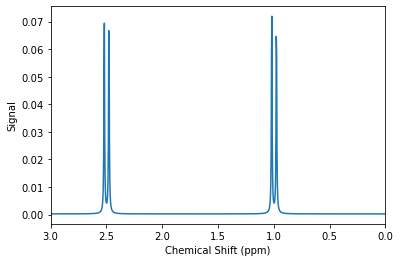

In [7]:
sim_fid.plot_spec(xlims=[3,0])

## Simulate a PRESS sequence with a shaped RF pulse for GPC
Note that the shaped pulse is only used for the 180 degree refocusing pulses. An ideal 90 degree pulse is still assumed for the initial excitation.

First load the RF pulse. A few example rf pulses are in the exampleData/rfPulses directly. It is possible the pass the filename to the pulse sequence directly, but loading the pulse into a pyFidA.RF_pulse object allows the plots to be inspected before running time-consuming simulations.

Siemens format .pta RF pulse file detected!! Loading waveform now.
Calculating time-w1max product
Calculating bandwidth


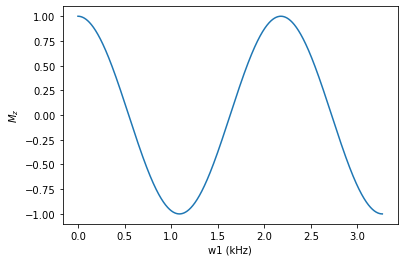

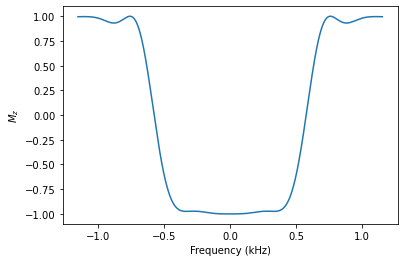

In [8]:
RF1=pyFidA.io_loadRFwaveform(os.path.join('..','..','exampleData','rfPulses','sampleRefocPulse.pta'),type_p='ref')

In [9]:
# NOTE: This simulation will take some time
spinSys=all_spin_systems['sysGPC']
# Simulate for a point at 0.75 cm from the middle of the voxel (in x and y)
dx=0.75
# Gradient (in G/cm) for a 1.5 cm thick slice
tp=4
Gx=RF1.tbw/(4)*1e-3/(RF1.gamma*1e-4)/1.5
sim_press=pyFidA.sim_press_shaped(npts=2048,sw=4000,Bfield=7,linewidth=2,spinSys=spinSys,tau1=7,tau2=7,RF1=RF1,tp=tp,dx=dx,dy=dx,Gx=Gx,Gy=Gx)

<AxesSubplot:xlabel='Chemical Shift (ppm)', ylabel='Signal'>

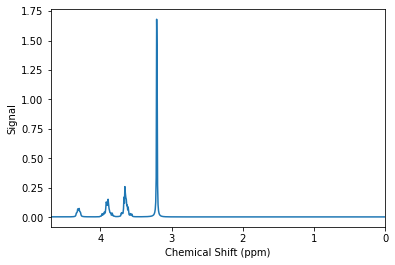

In [10]:
sim_press.plot_spec(xlims=[4.7,0])

## Simulate a user-defined sequence
Use the excitation, evolution and readout functions in the fidA_sim toolbox to construct your own sequence and run a simulation for it. Here, we simulate a 2D COSY sequence for a range of delay times (a version of this is also available in pyFidA.fidA_sim.sim_sequences.py) for alanine.

In [11]:
spinSys=all_spin_systems['sysAla']
sim_cosy=list()
# Simulate for a fairly small range of delays to keep the simulation short
# Note that delay times for sim_evolve are to be given in microseconds
delay_vec=np.linspace(2,15,100)/1000

# First, generate a Hamiltonian and density matrix for the spin system and field
H1,d1=pyFidA.sim_Hamiltonian(spinSys,Bfield=7,center_freq_ppm=4.65)
# Excitation pulse is the same for each delay time
d2=pyFidA.sim_excite(d1,H1,whichax='x',anglein=90)
# cycle through the specified delay times and collect a spectrum for each
for delay in delay_vec:
    d3=pyFidA.sim_evolve(d2,H1,delay)
    # Ideal pulses. No phase cycling
    d3=pyFidA.sim_excite(d3,H1,whichax='x',anglein=90)
    outtmp,dfinal=pyFidA.sim_readout(d3,H1,npts=2048,sw=4000,linewidth=2)
    sim_cosy.append(outtmp)

(6.0, 1.0)

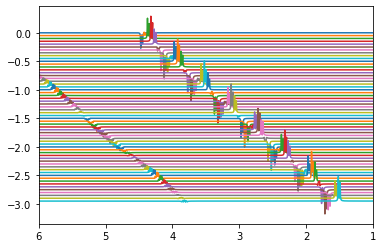

In [12]:
# Plot a subset of the spectra with different delays (offset to make them visible)
f1,ax1=plt.subplots(1,1)
for specct,eachspec in enumerate(sim_cosy[:60]):
    ax1.plot(len(sim_cosy[:60])*0.05+eachspec.ppm-specct*0.05,np.real(eachspec.specs-0.05*specct))
ax1.set_xlim([6,1])

Text(0, 0.5, 'Frequency (direct dim) ppm')

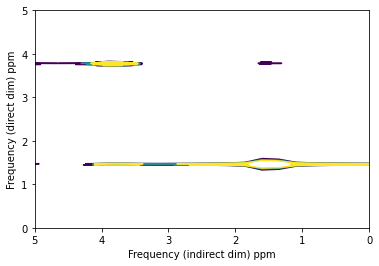

In [13]:
spec2d=np.array([eachspec.specs for eachspec in sim_cosy]).T
spec2d=fftshift(ifft(spec2d,axis=1),axes=1)
freq=fftshift(fftfreq(delay_vec.shape[-1],d=delay_vec[1]-delay_vec[0]))/300+4.65
f1,ax1=plt.subplots(1,1)
ax1.contour(freq,sim_cosy[0].ppm,np.abs(spec2d),levels=[0.008,0.01,0.012])
ax1.set_ylim([0,5])
ax1.set_xlim([5,0])
ax1.set_xlabel('Frequency (indirect dim) ppm')
ax1.set_ylabel('Frequency (direct dim) ppm')